# 手搓简易版 GBDT

## 生成数据

In [1]:
import numpy as np

# 生成带噪声的正弦曲线数据
np.random.seed(42)
X = np.sort(np.random.rand(200, 1) * 10, axis=0)
y = np.sin(X).ravel() + np.random.randn(200) * 0.2

## 手动实现

In [2]:
n_trees = 9                   # 树的总量
learning_rate = 0.3           # 学习率
trees = []                    # 树的容器
F = np.full_like(y, y.mean()) # 步骤1：用均值初始化

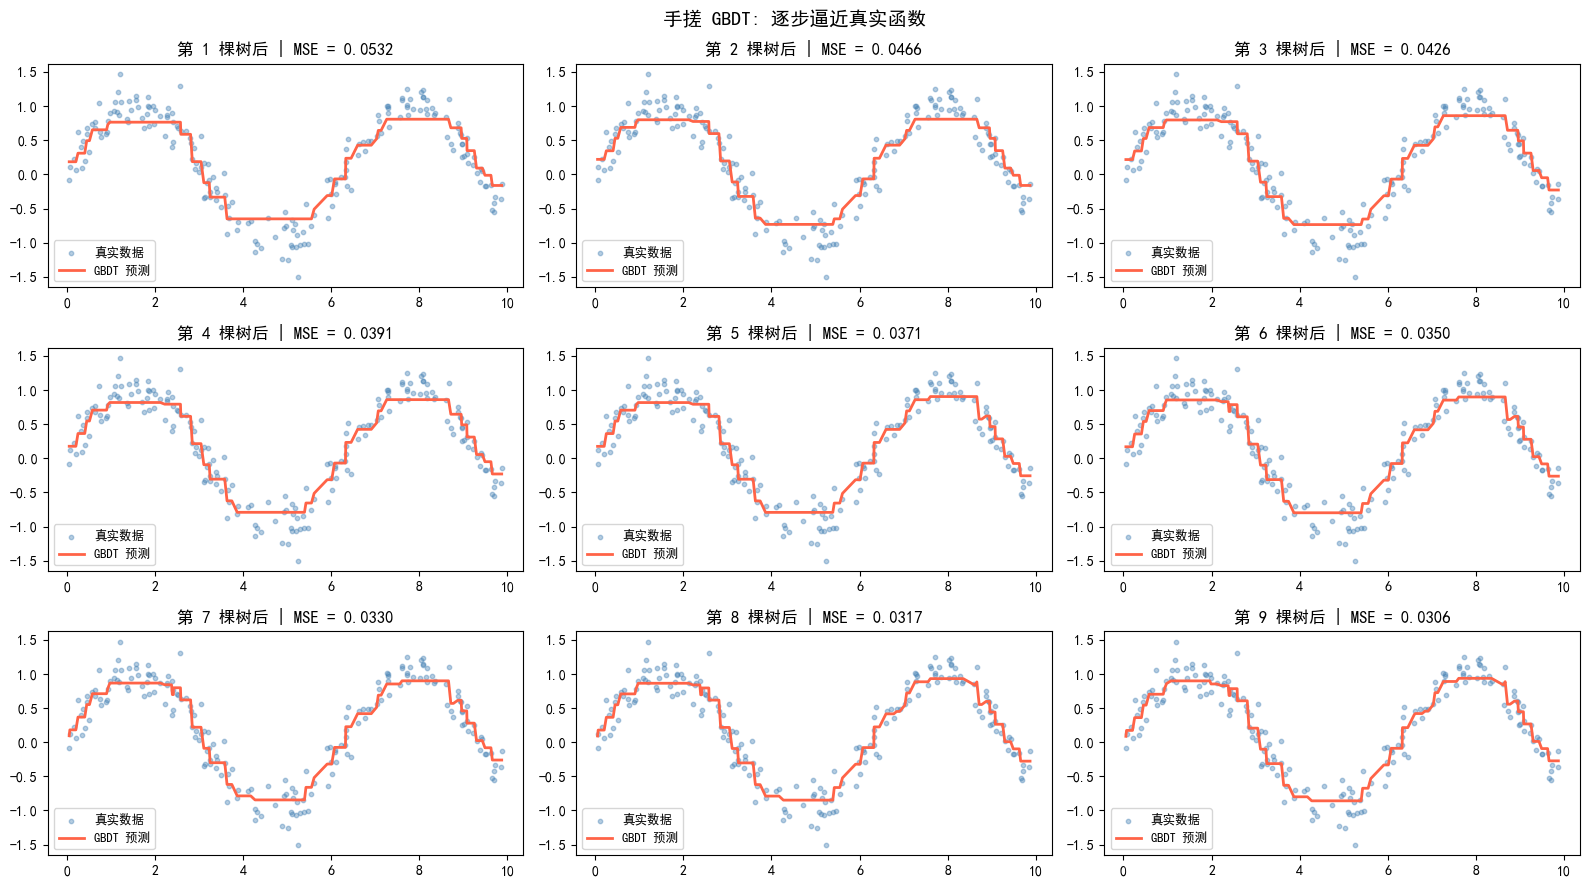

In [4]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
fig, axes = plt.subplots(3, 3, figsize = (16, 9))

for i in range(n_trees):
  # 计算残差（MSE下的负梯度）
  residual = y - F

  # 用一棵浅树拟合残差
  tree = DecisionTreeRegressor(max_depth= 2)
  tree.fit(X, residual)
  pred = tree.predict(X)
  trees.append(tree)

  # 更新模型
  F += learning_rate * pred

  # 可视化
  mse = np.mean((y - F) ** 2)
  ax = axes[i // 3][i % 3] # 子图行列
  ax.scatter(X, y, s = 10, alpha = 0.4, color = 'steelblue', label = '真实数据')
  ax.plot(X, F, color = 'tomato', linewidth = 2, label = f'GBDT 预测')
  ax.set_title(f'第 {i + 1} 棵树后 | MSE = {mse:.4f}', fontsize = 12)
  ax.legend(fontsize = 9)

plt.suptitle('手搓 GBDT: 逐步逼近真实函数', fontsize = 14, fontweight = 'bold')
plt.tight_layout()
plt.show()

每棵新树都在查漏补缺，模型一轮比一轮精准
- 第 1~3 棵树：红色曲线只是一个粗略的阶梯形，MSE 较大
- 第 4~6 棵树：曲线开始有了正弦的轮廓，MSE 明显下降
- 第 7~9 棵树：曲线越来越贴合蓝色散点，MSE 持续缩小

## 观察残差

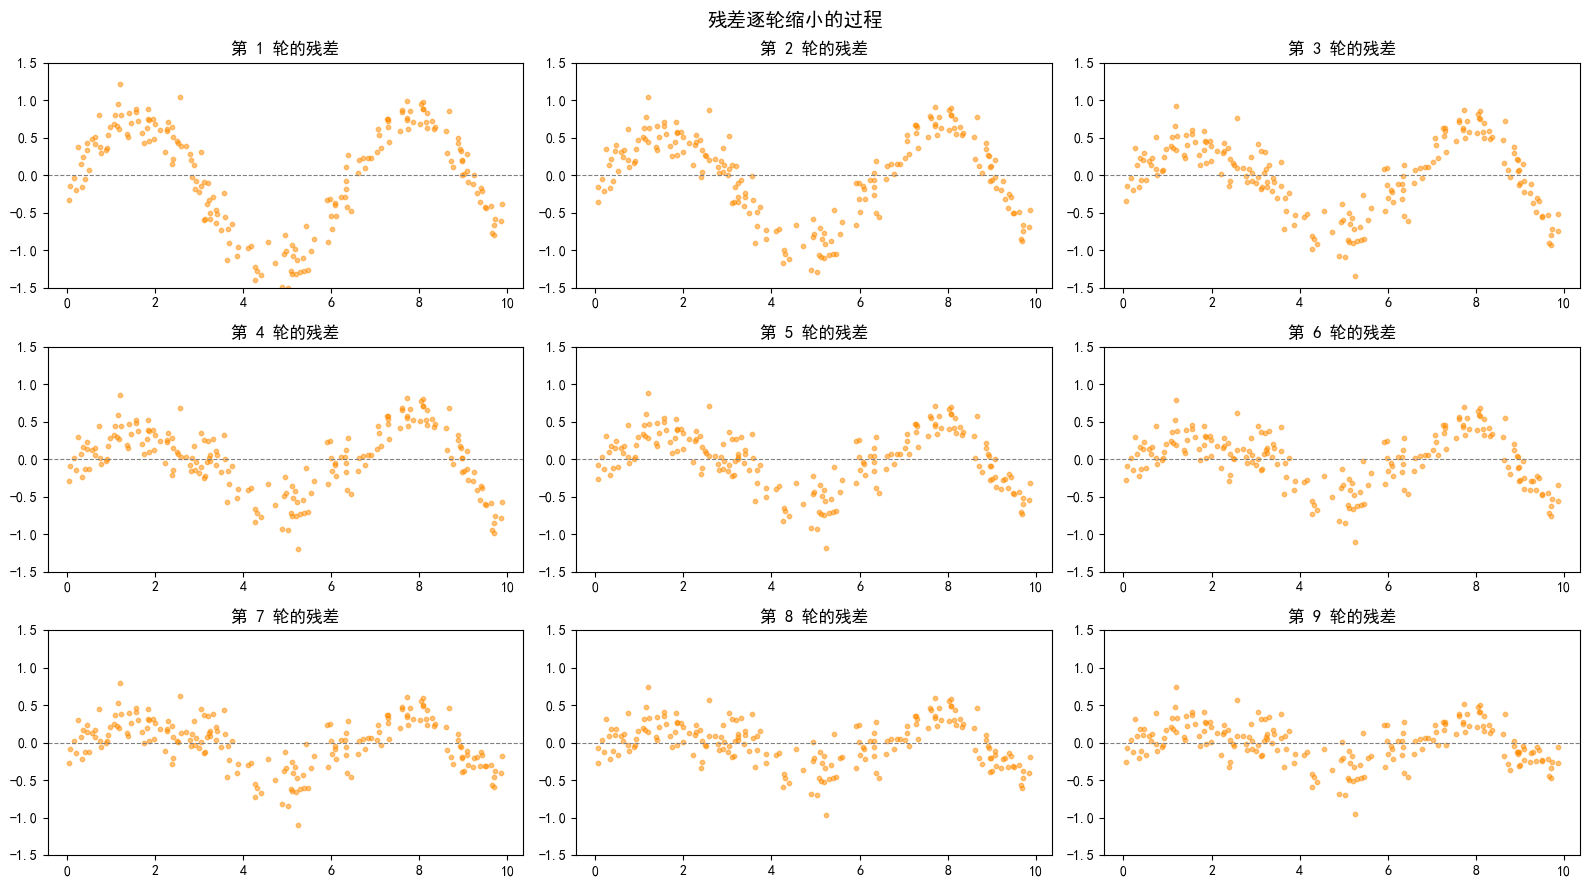

In [14]:
fig, axes = plt.subplots(3, 3, figsize=(16, 9))
F = np.full_like(y, y.mean())

for i in range(n_trees):
    residual = y - F
    tree = DecisionTreeRegressor(max_depth=2)
    tree.fit(X, residual)
    F += learning_rate * tree.predict(X)

    ax = axes[i // 3][i % 3]
    ax.scatter(X, residual, s=10, alpha=0.5, color='darkorange')
    ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.8)
    ax.set_title(f'第 {i + 1} 轮的残差', fontsize=12)
    ax.set_ylim(-1.5, 1.5)

plt.suptitle('残差逐轮缩小的过程', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

橙色散点（残差）逐轮向零线收敛，这正是 Boosting 逐步纠错的过程

# XGBoost 演示

## 准备数据

In [9]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

# 加载加州房价数据集
data = fetch_california_housing()
X, y = data.data, data.target
feature_names = data.feature_names

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"训练集大小: {X_train.shape}")
print(f"测试集大小: {X_test.shape}")
print(f"特征: {feature_names}")

训练集大小: (16512, 8)
测试集大小: (4128, 8)
特征: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


## 训练模型
>避坑指南：macOS 用户运行前先 brew install libomp，否则 XGBoost 会报错。

### RandomForest

In [10]:
import time
from sklearn.ensemble import RandomForestRegressor

# --- 随机森林 ---
rf_start = time.time()         # 记录启动时间
rf = RandomForestRegressor(
  n_estimators= 200,        # 200棵树
  max_depth= 10,            # 最深10层
  random_state= 42,         # 随机种子
  n_jobs= -1                # CPU 并行加速
)

rf.fit(X_train, y_train)
rf_time = time.time() - rf_start
rf_pred = rf.predict(X_test)


### XGBoost

In [11]:
from xgboost import XGBRegressor

# --- XGBoost ---
xgb_start = time.time()
xgb = XGBRegressor(
  n_estimators = 200,     # 200棵树
  max_depth = 5,          # 最深5层
  learning_rate = 0.1,    # 学习率
  subsample = 0.8,        # 每次训练抽选样本比例
  colsample_bytree = 0.8, # 每次训练抽选特征比例
  random_state = 42,      # 随机种子
  n_jobs = -1,            # CPU 并行加速
)
xgb.fit(X_train, y_train)
xgb_time = time.time() - xgb_start
xgb_pred = xgb.predict(X_test)


## 对比结果

In [12]:
from sklearn.metrics import mean_squared_error, r2_score

# ---- 结果对比 ----
print("=" * 50)
print(f"{'指标':<15} {'随机森林':>12} {'XGBoost':>12}")
print("=" * 50)
print(f"{'MSE':<15} {mean_squared_error(y_test, rf_pred):>12.4f} "
      f"{mean_squared_error(y_test, xgb_pred):>12.4f}")
print(f"{'R² Score':<15} {r2_score(y_test, rf_pred):>12.4f} "
      f"{r2_score(y_test, xgb_pred):>12.4f}")
print(f"{'训练时间(秒)':<15} {rf_time:>12.2f} {xgb_time:>12.2f}")

指标                      随机森林      XGBoost
MSE                   0.2951       0.2175
R² Score              0.7748       0.8340
训练时间(秒)                 3.09         0.22


## 早停防过拟合

In [13]:
from xgboost import XGBRegressor

xgb_es = XGBRegressor(
  n_estimators=10000,        # 设一个很大的上限
  max_depth=5,
  learning_rate=0.05,       # 用更小的学习率
  subsample=0.8,
  colsample_bytree=0.8,
  random_state=42,
  early_stopping_rounds=20  # 20轮不提升就停止
)

xgb_es.fit(
  X_train, y_train,
  eval_set=[(X_test, y_test)],
  verbose=50                # 每50轮打印一次
)

print(f"\n最佳迭代轮数: {xgb_es.best_iteration}")
print(f"最佳MSE: {mean_squared_error(y_test, xgb_es.predict(X_test)):.4f}")

[0]	validation_0-rmse:1.10965
[50]	validation_0-rmse:0.58442
[100]	validation_0-rmse:0.51834
[150]	validation_0-rmse:0.49751
[200]	validation_0-rmse:0.48475
[250]	validation_0-rmse:0.47580
[300]	validation_0-rmse:0.46949
[350]	validation_0-rmse:0.46579
[400]	validation_0-rmse:0.46165
[450]	validation_0-rmse:0.45851
[500]	validation_0-rmse:0.45647
[550]	validation_0-rmse:0.45376
[600]	validation_0-rmse:0.45138
[650]	validation_0-rmse:0.45000
[700]	validation_0-rmse:0.44883
[750]	validation_0-rmse:0.44751
[800]	validation_0-rmse:0.44649
[850]	validation_0-rmse:0.44570
[900]	validation_0-rmse:0.44504
[914]	validation_0-rmse:0.44482

最佳迭代轮数: 894
最佳MSE: 0.1979


## 可视化训练过程

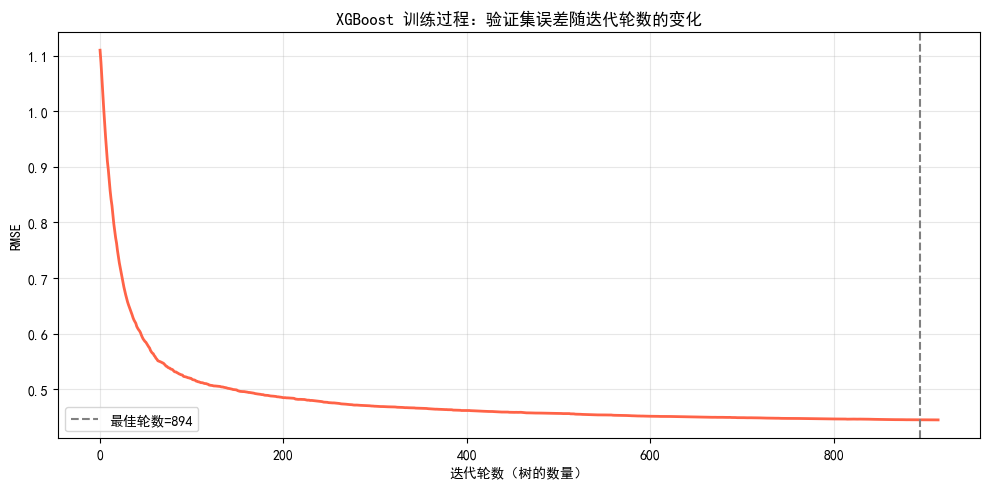

In [14]:
# 获取训练过程中的损失变化
results = xgb_es.evals_result()

plt.figure(figsize=(10, 5))
plt.plot(results['validation_0']['rmse'], color='tomato', linewidth=2)
plt.xlabel('迭代轮数（树的数量）')
plt.ylabel('RMSE')
plt.title('XGBoost 训练过程：验证集误差随迭代轮数的变化')
plt.axvline(x=xgb_es.best_iteration, color='gray',
            linestyle='--', label=f'最佳轮数={xgb_es.best_iteration}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

会看到验证集的 RMSE 先快速下降，然后趋于平缓，最终可能略微上升（过拟合的信号），Early Stopping 恰好在最低点附近停下来。

## 回归决策树可视化：理解"残差分叉"

回归树和分类树结构一样，都是 if-else 分支。区别在于**叶子节点的输出值**和**分裂依据**。下面用一个极简数据集来具象化。  


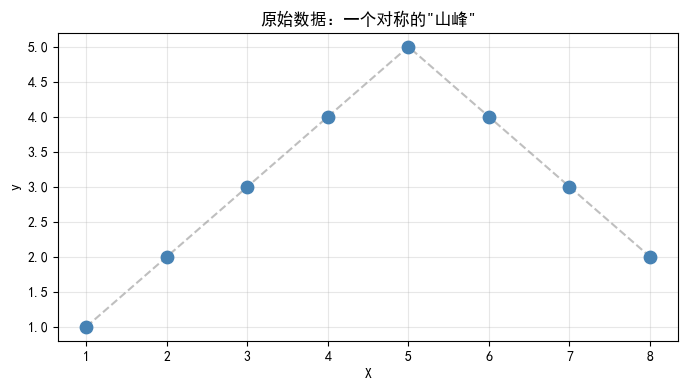

In [15]:
# ── 1. 造一个极简数据集 ──
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, plot_tree

# 仅 8 个样本，方便手算
X_simple = np.array([1, 2, 3, 4, 5, 6, 7, 8]).reshape(-1, 1)
y_simple = np.array([1.0, 2.0, 3.0, 4.0, 5.0, 4.0, 3.0, 2.0])

plt.figure(figsize=(8, 4))
plt.scatter(X_simple, y_simple, s=80, color='steelblue', zorder=3)
plt.plot(X_simple, y_simple, '--', color='gray', alpha=0.5)  # 连线展示趋势
plt.xlabel('X')
plt.ylabel('y')
plt.title('原始数据：一个对称的"山峰"')
plt.grid(alpha=0.3)
plt.show()

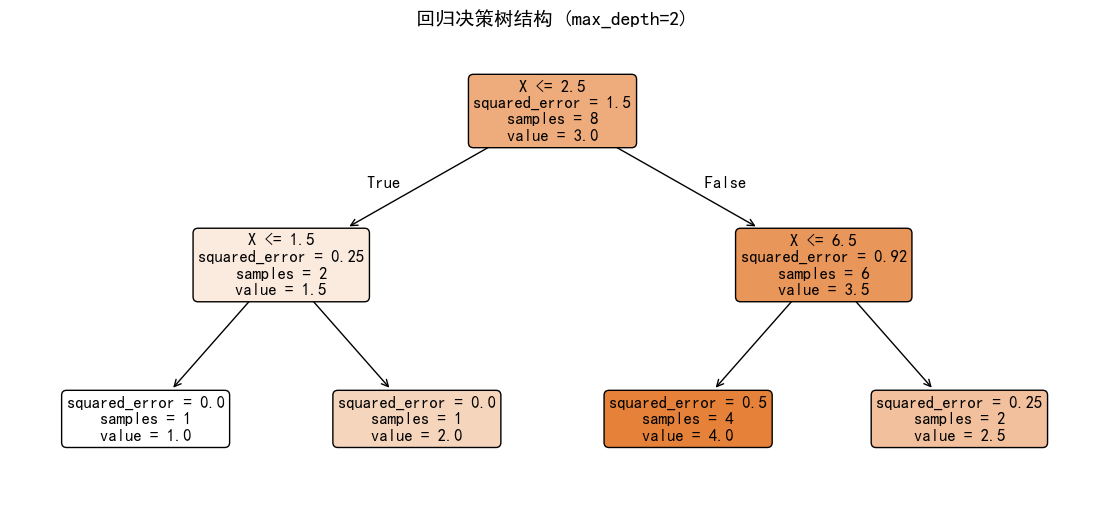


预测值: [1.  2.  4.  4.  4.  4.  2.5 2.5]
真实值:  [1. 2. 3. 4. 5. 4. 3. 2.]


In [16]:
# ── 2. 训练一棵回归树并可视化树结构 ──
tree_simple = DecisionTreeRegressor(max_depth=2, random_state=42)
tree_simple.fit(X_simple, y_simple)

# 用 plot_tree 画出决策树的 if-else 结构
plt.figure(figsize=(14, 6))
plot_tree(
    tree_simple,
    feature_names=['X'],
    filled=True,
    rounded=True,
    fontsize=12,
    precision=2,
    impurity=True,      # 显示 MSE
)
plt.title('回归决策树结构 (max_depth=2)', fontsize=14, fontweight='bold')
plt.show()

# 打印每个叶子节点的预测值
print(f"\n预测值: {tree_simple.predict(X_simple)}")
print(f"真实值:  {y_simple}")

In [17]:
# ── 3. 手算每个可能分叉点的 MSE ──
# 搞懂：回归树的分裂依据是"让两边数值方差之和最小"

def calc_split_mse(X, y, threshold):
    """计算在 threshold 处分裂后的加权 MSE"""
    left = y[X.ravel() <= threshold]
    right = y[X.ravel() > threshold]
    w_left = len(left) / len(y)
    w_right = len(right) / len(y)
    # 叶子节点输出 = 均值 → MSE = 方差
    mse_left = np.mean((left - left.mean())**2) if len(left) > 0 else 0
    mse_right = np.mean((right - right.mean())**2) if len(right) > 0 else 0
    return w_left * mse_left + w_right * mse_right

# 尝试所有相邻 X 的中点作为候选分叉点
candidates = (X_simple[:-1] + X_simple[1:]) / 2
original_mse = np.mean((y_simple - y_simple.mean())**2)

print(f"{'分叉点':>8} {'左样本':>8} {'右样本':>8} {'加权MSE':>10} {'MSE下降':>10}")
print("-" * 46)
for th in candidates.ravel():
    split_mse = calc_split_mse(X_simple, y_simple, th)
    reduction = original_mse - split_mse
    left_vals = y_simple[X_simple.ravel() <= th]
    right_vals = y_simple[X_simple.ravel() > th]
    print(f"X <= {th:.1f}  {str(left_vals):>20} {str(right_vals):>20} {split_mse:>10.4f} {reduction:>10.4f}")

print(f"\n原始总MSE（所有样本预测为均值 {y_simple.mean():.2f}）: {original_mse:.4f}")
print("→ 回归树找到使加权 MSE 最小的分叉点，把数值相近的样本分到同一边。")

     分叉点      左样本      右样本      加权MSE      MSE下降
----------------------------------------------
X <= 1.5                  [1.] [2. 3. 4. 5. 4. 3. 2.]     0.9286     0.5714
X <= 2.5               [1. 2.]  [3. 4. 5. 4. 3. 2.]     0.7500     0.7500
X <= 3.5            [1. 2. 3.]     [4. 5. 4. 3. 2.]     0.9000     0.6000
X <= 4.5         [1. 2. 3. 4.]        [5. 4. 3. 2.]     1.2500     0.2500
X <= 5.5      [1. 2. 3. 4. 5.]           [4. 3. 2.]     1.5000     0.0000
X <= 6.5   [1. 2. 3. 4. 5. 4.]              [3. 2.]     1.4167     0.0833
X <= 7.5  [1. 2. 3. 4. 5. 4. 3.]                 [2.]     1.3571     0.1429

原始总MSE（所有样本预测为均值 3.00）: 1.5000
→ 回归树找到使加权 MSE 最小的分叉点，把数值相近的样本分到同一边。


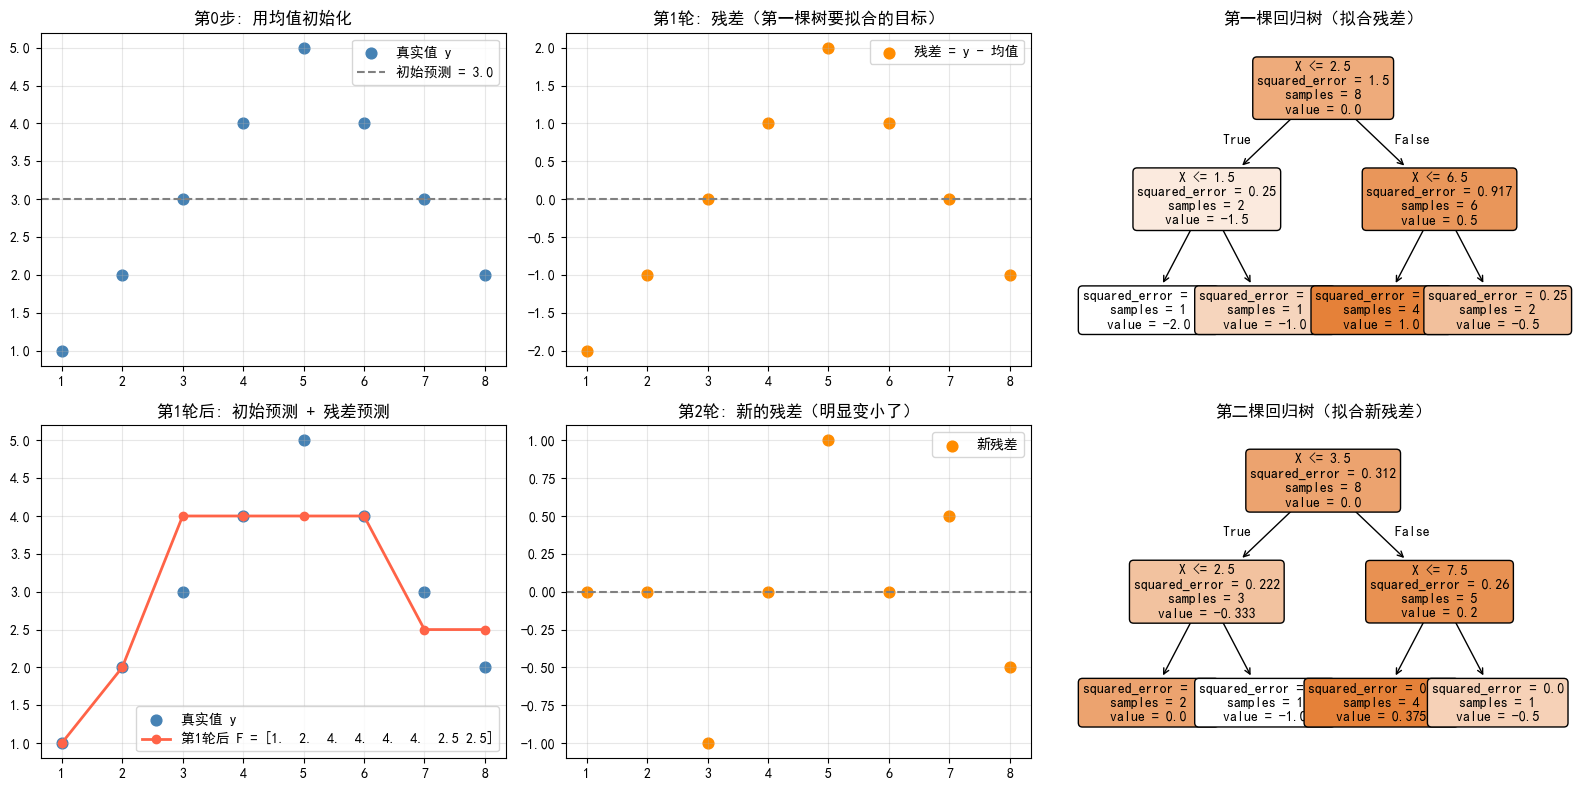

轮次       预测 F                                  MSE
------------------------------------------------
初始       [3. 3. 3. 3. 3. 3. 3. 3.]          1.5000
第1轮      [1.  2.  4.  4.  4.  4.  2.5 2.5]     0.3125
第2轮      [1.   2.   3.   4.38 4.38 4.38 2.88 2.  ]     0.0859


In [18]:
# ── 4. 🔥 关键！用残差拟合第二棵树 ──
# 模拟 GBDT 的第一步：用均值初始化
F0 = np.full_like(y_simple, y_simple.mean())
residual_1 = y_simple - F0  # 第一轮残差

# 第一棵树：拟合残差
tree1 = DecisionTreeRegressor(max_depth=2, random_state=42)
tree1.fit(X_simple, residual_1)

# 计算第二轮残差（学习率 = 1.0 方便观察）
F1 = F0 + 1.0 * tree1.predict(X_simple)
residual_2 = y_simple - F1

# 第二棵树：拟合新的残差
tree2 = DecisionTreeRegressor(max_depth=2, random_state=42)
tree2.fit(X_simple, residual_2)

# ── 可视化 ──
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

# 第一行：GBDT 第 1 轮
axes[0, 0].scatter(X_simple, y_simple, s=60, color='steelblue', label='真实值 y')
axes[0, 0].axhline(y=F0[0], color='gray', linestyle='--', label=f'初始预测 = {F0[0]:.1f}')
axes[0, 0].set_title('第0步: 用均值初始化')
axes[0, 0].legend(); axes[0, 0].grid(alpha=0.3)

axes[0, 1].scatter(X_simple, residual_1, s=60, color='darkorange', label='残差 = y - 均值')
axes[0, 1].axhline(y=0, color='gray', linestyle='--')
axes[0, 1].set_title('第1轮: 残差（第一棵树要拟合的目标）')
axes[0, 1].legend(); axes[0, 1].grid(alpha=0.3)

plot_tree(tree1, feature_names=['X'], filled=True, rounded=True,
          ax=axes[0, 2], fontsize=10)
axes[0, 2].set_title('第一棵回归树（拟合残差）')

# 第二行：GBDT 第 2 轮
axes[1, 0].scatter(X_simple, y_simple, s=60, color='steelblue', label='真实值 y')
axes[1, 0].plot(X_simple, F1, 'o-', color='tomato', linewidth=2, label=f'第1轮后 F = {F1.round(1)}')
axes[1, 0].set_title('第1轮后: 初始预测 + 残差预测')
axes[1, 0].legend(); axes[1, 0].grid(alpha=0.3)

axes[1, 1].scatter(X_simple, residual_2, s=60, color='darkorange', label='新残差')
axes[1, 1].axhline(y=0, color='gray', linestyle='--')
axes[1, 1].set_title('第2轮: 新的残差（明显变小了）')
axes[1, 1].legend(); axes[1, 1].grid(alpha=0.3)

plot_tree(tree2, feature_names=['X'], filled=True, rounded=True,
          ax=axes[1, 2], fontsize=10)
axes[1, 2].set_title('第二棵回归树（拟合新残差）')

plt.tight_layout()
plt.show()

print(f"{'轮次':<8} {'预测 F':<30} {'MSE':>10}")
print("-" * 48)
print(f"{'初始':<8} {str(F0.round(2)):<30} {np.mean((y_simple-F0)**2):>10.4f}")
print(f"{'第1轮':<8} {str(F1.round(2)):<30} {np.mean((y_simple-F1)**2):>10.4f}")
print(f"{'第2轮':<8} {str((F1+tree2.predict(X_simple)).round(2)):<30} {np.mean((y_simple-(F1+tree2.predict(X_simple)))**2):>10.4f}")

### 总结：回归树的"残差分叉"到底指什么？

回到你的 GBDT 代码 `tree.fit(X, residual)`，拆开来看：

**① 回归树本身的分叉依据（MSE）**

```
在 X <= 2.5 处分叉？
  → 左节点: y=[1,2]  均值=1.5, MSE=0.25
  → 右节点: y=[3,4,5,4,3,2] 均值=3.5, MSE=0.92
  → 加权 MSE = 2/8×0.25 + 6/8×0.92 = 0.75 ← 很小，是个好分叉！
```

回归树找分叉点不是"乱分"的，而是**枚举所有分叉点，选加权 MSE 最小的那个**。MSE 小意味着该叶子内的数值很接近，预测误差就小。

**② GBDT 的特殊之处：y 换成了残差**

普通回归树：`tree.fit(X, y_simple)` → 树直接拟合原始数值。

GBDT 里的回归树：`tree.fit(X, residual)` → 树拟合的是**当前误差**。

```
第 1 轮：残差 = y - 均值
  → 第一棵树看到的是 [−2, −1, 0, 1, 2, 1, 0, −1]
  → 它用 MSE 准则在这些残差上分叉：把大的正残差和大的负残差分开
  → 预测出残差后，加到旧模型上 → 误差缩小

第 2 轮：残差 = y - (均值 + 第一棵树预测)
  → 第二棵树看到的残差已经变小了
  → 继续重复...
```

**③ 类比**

| | 分类树 | 回归树 | GBDT 中的回归树 |
|---|---|---|---|
| 分叉 | if-else | if-else | if-else（结构一样！） |
| 分裂依据 | Gini 系数 | **MSE（方差）** | **MSE（方差）** |
| 叶子输出 | 多数类别 | **残差的均值** | **残差的均值** |
| 目标 | 判断类别 | 预测数值 | **修补上一轮的误差** |

**树的 if-else 结构始终没变，变的只是每个叶子节点里装的值（连续均值而非离散类别）和分裂的评判标准（MSE 而非 Gini）。而 GBDT 只是额外多了一层——这些树拟合的是"残差"而非"原始 y"。**
